In [1]:
#!/bin/env python3

import os, re
import bids
from nilearn import image as nimg
from nilearn import plotting as nplot
from nilearn.plotting import plot_design_matrix
import nilearn.glm.first_level
import pandas as pd
import numpy as np
import logging
import argparse
import glob

In [2]:
#set your paths
task='epiproj'
ses=2
basedir = os.path.join("/home/jovyan/panmvpa")
funcdir = os.path.join(basedir, "ds006598-download/sub-PAN01/ses-%i/func" %(ses))
func_files = glob.glob(os.path.join(funcdir,'*ses-%i_task-%s*.nii.gz' %(ses, task)))
func_files

['/home/jovyan/panmvpa/ds006598-download/sub-PAN01/ses-2/func/sub-PAN01_ses-2_task-epiproj_space-MNI152NLin6Asym_res-2_desc-preproc_bold.nii.gz']

In [3]:
#append data for fixed effects model
design_matrices = []
fmri_img = []
func_tr = 1.355

In [4]:
func_img = nimg.load_img(func_files)
fmri_img.append(func_img)

In [15]:
#read fmri volumes in seconds
frame_times = np.arange(func_img.shape[-1]) * func_tr
frame_times

array([  0.   ,   1.355,   2.71 ,   4.065,   5.42 ,   6.775,   8.13 ,
         9.485,  10.84 ,  12.195,  13.55 ,  14.905,  16.26 ,  17.615,
        18.97 ,  20.325,  21.68 ,  23.035,  24.39 ,  25.745,  27.1  ,
        28.455,  29.81 ,  31.165,  32.52 ,  33.875,  35.23 ,  36.585,
        37.94 ,  39.295,  40.65 ,  42.005,  43.36 ,  44.715,  46.07 ,
        47.425,  48.78 ,  50.135,  51.49 ,  52.845,  54.2  ,  55.555,
        56.91 ,  58.265,  59.62 ,  60.975,  62.33 ,  63.685,  65.04 ,
        66.395,  67.75 ,  69.105,  70.46 ,  71.815,  73.17 ,  74.525,
        75.88 ,  77.235,  78.59 ,  79.945,  81.3  ,  82.655,  84.01 ,
        85.365,  86.72 ,  88.075,  89.43 ,  90.785,  92.14 ,  93.495,
        94.85 ,  96.205,  97.56 ,  98.915, 100.27 , 101.625, 102.98 ,
       104.335, 105.69 , 107.045, 108.4  , 109.755, 111.11 , 112.465,
       113.82 , 115.175, 116.53 , 117.885, 119.24 , 120.595, 121.95 ,
       123.305, 124.66 , 126.015, 127.37 , 128.725, 130.08 , 131.435,
       132.79 , 134.

In [23]:
ses=2
stimdir = os.path.join(basedir, "ds006598-download/derivatives/afni_timing/PAN01")
eventsfile = os.path.join(stimdir,'ses%i_%s_3col.txt' %(ses, task))
header = ["onset", "duration","trial_type"]
events = pd.read_table(eventsfile, names=header, header=0)
print(eventsfile, events)
#events_files = glob.glob(os.path.join(stimdir,"*ses-%i_task-%s*" %(ses, task)))
#eventsfile = list(events_files)[1]
#events = pd.read_table(eventsfile, header=None)

/home/jovyan/panmvpa/ds006598-download/derivatives/afni_timing/PAN01/ses2_epiproj_3col.txt     onset  duration trial_type
0      37        10    trial 2
1      57        10    trial 3
2      77        10    trial 4
3      97        10    trial 5
4     117        10    trial 6
5     137        10    trial 7
6     157        10    trial 8
7     177        10    trial 9
8     197        10   trial 10
9     217        10   trial 11
10    237        10   trial 12
11    257        10   trial 13
12    277        10   trial 14
13    297        10   trial 15
14    317        10   trial 16
15    337        10   trial 17
16    357        10   trial 18
17    377        10   trial 19
18    397        10   trial 20
19    417        10   trial 21
20    437        10   trial 22
21    457        10   trial 23
22    477        10   trial 24
23    497        10   trial 25
24    517        10   trial 26
25    537        10   trial 27
26    557        10   trial 28
27    577        10   trial 29
28    597 

In [7]:
design = nilearn.glm.first_level.make_first_level_design_matrix(frame_times, events,drift_model=None,high_pass=0.01,hrf_model='spm')
design_matrices.append(design)

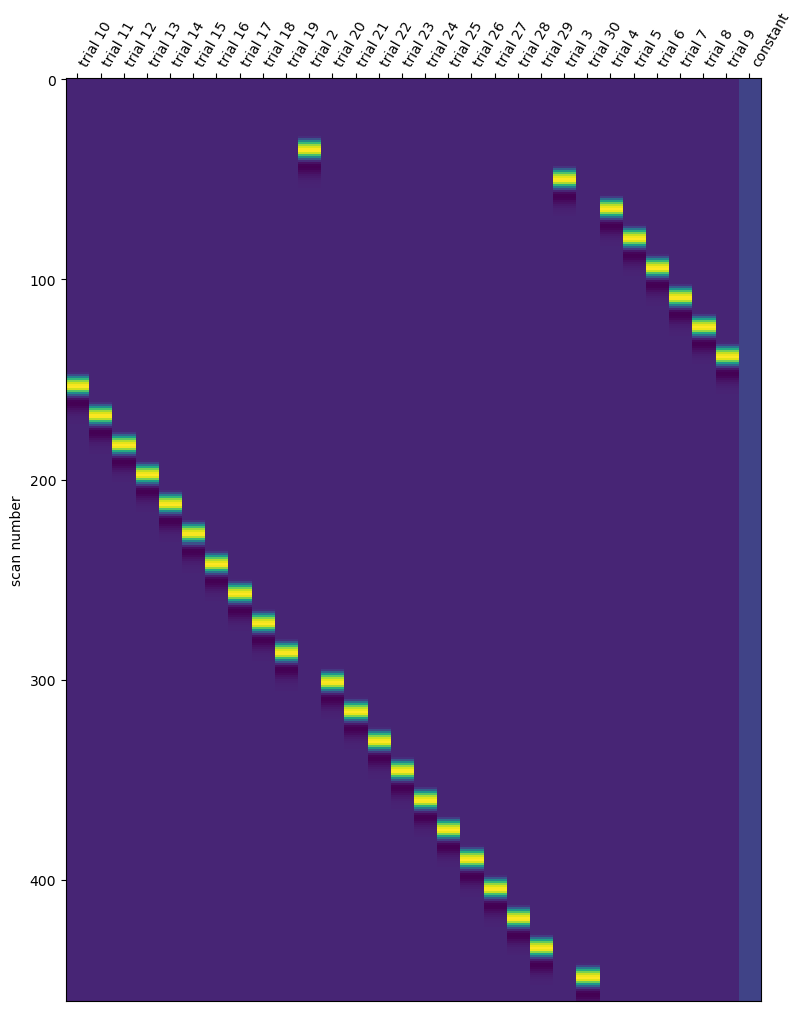

In [8]:
designplot = plot_design_matrix(design_matrices)
#design.to_csv(os.path.join(stimdir,"PAN01_ses1_epiproj_design.csv"))

In [13]:
#setup basic contrasts
contrast_matrix = np.eye(design.shape[1])
basic_contrasts = dict([(column, contrast_matrix[i]) for i, column in enumerate(design.columns)])
print(basic_contrasts)

{'trial 10': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'trial 11': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'trial 12': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'trial 13': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'trial 14': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'trial 15': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'trial 16': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0

In [26]:
fmri_glm = nilearn.glm.first_level.FirstLevelModel(n_jobs=8,smoothing_fwhm=4, t_r=func_tr)
#fmri_glm = fmri_glm.fit(fmri_img,design_matrices=design)
fmri_glm = fmri_glm.fit(fmri_img,design_matrices=design_matrices)
report = fmri_glm.generate_report(basic_contrasts)
report.save_as_html(os.path.join(basedir,'PAN01_epiproj_trialev_ses2/report_alltrials.html'))

/tmp/ipykernel_8017/3606301915.py:3: UserWarning: If design matrices are supplied, [t_r] will be ignored.
  fmri_glm = fmri_glm.fit(fmri_img,design_matrices=design_matrices)


In [ ]:
##saves contrasts to nii files and generates plots#
#do a fixed effects model combining the runs
outdir=os.path.join(basedir,'PAN01_epiproj_trialev_ses2')
bg_img = nimg.mean_img(fmri_img)
for index, (contrast_id, contrast_val) in enumerate(basic_contrasts.items()):
    print('  Contrast % 2i out of %i: %s' % (index + 1, len(basic_contrasts), contrast_id))
    z_map = fmri_glm.compute_contrast(contrast_val, output_type='effect_size')
    # write the resulting stat images to file
    z_image_path = os.path.join(outdir, '%s_%s_beta_map.nii.gz' % (task,contrast_id))
    z_map.to_filename(z_image_path)
    display = nplot.plot_stat_map(z_map, bg_img=bg_img, threshold=2.0, title="%s" % (contrast_id,), display_mode='z', cut_coords=3, black_bg=True)
    display.savefig(os.path.join(outdir,"%s_%s.png" % (task,contrast_id,)))